In [1]:
# !gdown https://drive.google.com/file/d/1cHrLgf_7xScBHxnvnlCkvAy_iYGscN3w

Project Description: Hand Gesture Classification Using MediaPipe Landmarks from the HaGRID Dataset

Overview:
In this project, students will work on classifying hand gestures using landmark data generated by MediaPipe from the HaGRID (Hand Gesture Recognition Image Dataset).
The input to the project is a CSV file containing hand landmarks (e.g., x, y, z coordinates of keypoints) extracted from the HaGRID dataset using MediaPipe. The output will be a trained machine learning model capable of classifying hand gestures into predefined classes.

Students will gain hands-on experience in data preprocessing, visualization, machine learning model training, and performance evaluation. They will also learn how to document their work in a reproducible format and present their results effectively.

Dataset Details:
The HaGRID dataset contains 18 classes of hand gestures, including:  
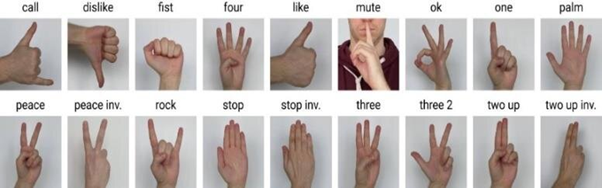


Each gesture is represented by a set of hand landmarks (21 landmarks per hand) extracted using MediaPipe. The CSV file will contain these landmarks(x,y,z location) along with their corresponding gesture labels.  

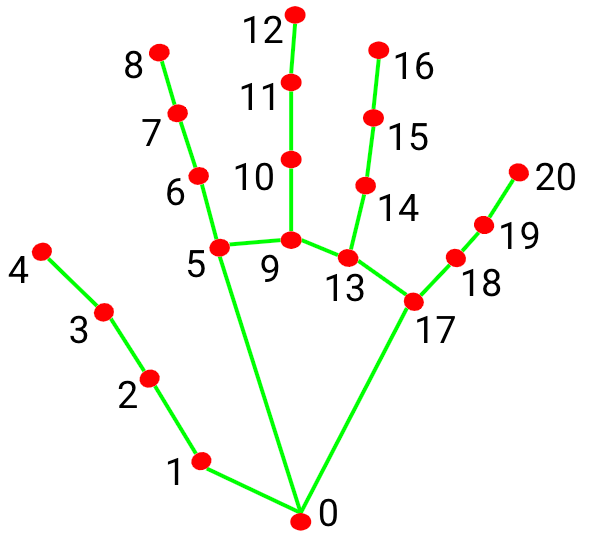

Project Deliverables:
Students are required to deliver the following:
1. Google Colab Notebook:
- A well-documented and executable Colab notebook uploaded to GitHub.
- The notebook should include:
- Data Loading: Loading the CSV file containing hand landmarks and labels.
- Data Visualization: Visualizing the hand landmarks (e.g., plotting keypoints for a few samples).
- Data Preprocessing: Cleaning, normalizing, and preparing the data for training (e.g., handling missing values, splitting into train/test sets).
- Model Training: Implementing and comparing at least 3 machine learning models (e.g., Random Forest, SVM) for gesture classification.
- Evaluation: Reporting accuracy, precision, recall, and F1-score for each model.
- Conclusion: Summarizing the results and selecting the best-performing model.

1. Output Video:
You will find a video sample in the project folder
- A short video demonstrating the results of the trained model.
- Upload the video to google drive and share a link
- You need to use mediapipe to get the hands landmarks in each frame
Evaluation Criteria:
1. Code Quality: Clean, well-documented, and reproducible code.
2. Model Performance: Accuracy and robustness of the trained models.
3. Visualization: Clarity and effectiveness of data and results visualization.

Notes:
- The detected hands have different scales and positions in the image. To overcome this problem recenter the hand landmarks (x,y) to make the origin the wrist point and divide all the landmarks by the mid-finger tip position.
With that all the detected hands will be similar in training and testing data.
z location doesn’t need to be processed as it is already processed.
- You can stabilize the output of the video by taking the mode of the outputs over a window
- Before sharing the github and video links with me, be sure that they are public and that I will be able to access them.

# Import Libraries

Uncomment the following cell to install any missing dependencies

In [2]:
# !pip install mediapipe==0.10.14 opencv-python pandas scikit-learn matplotlib seaborn mlflow -q

In [3]:
import pandas as pd
import numpy as np
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

### Preprocess Landmarks
Takes a list or array of 63 values (21 landmarks * 3 coordinates x,y,z).
    1. Recenters all points so the wrist (landmark 0) is at (0,0,0).
    2. Scales all points by the distance to the middle finger tip (landmark 12).

# Load and Preprocess Data

In [4]:
def preprocess_landmarks(row_or_landmarks):
    # Reshape flat array into (21, 3) for easier manipulation
    points = np.array(row_or_landmarks).reshape(21, 3)
    
    # Landmark 0 is the wrist, Landmark 12 is the middle finger tip
    wrist = points[0]

    centered_points = points - wrist

    mid_finger_tip = centered_points[12]
    scale_factor = np.linalg.norm(mid_finger_tip) + 1e-6 # Prevent division by zero
    
    normalized_points = centered_points / scale_factor
    
    # Flatten back to 63 values
    return normalized_points.flatten()

In [5]:
import numpy as np
from itertools import combinations

def preprocess_and_engineer(row_or_landmarks):
    """
    1. Recenters to wrist.
    2. Scales by mid-finger tip.
    3. Engineers specific hand-geometry features.
    """
    # Reshape flat array into (21, 3)
    points = np.array(row_or_landmarks).reshape(21, 3)
    wrist = points[0]
    
    # 1 & 2: Recenter and Scale
    centered_points = points - wrist
    mid_finger_tip = centered_points[12]
    scale_factor = np.linalg.norm(mid_finger_tip) + 1e-6
    normalized_points = centered_points / scale_factor
    
    # Start our feature list with the 63 normalized coordinates
    features = list(normalized_points.flatten())
    
    # --- FEATURE ENGINEERING ---
    
    # Key landmark indices
    # Thumb: 4, Index: 8, Middle: 12, Ring: 16, Pinky: 20
    fingertips = [4, 8, 12, 16, 20]
    
    # Feature A: Distances between all pairs of fingertips (10 features)
    for i, j in combinations(fingertips, 2):
        dist = np.linalg.norm(normalized_points[i] - normalized_points[j])
        features.append(dist)
        
    # Feature B: Distance from each fingertip to the wrist (5 features)
    # Since wrist is at (0,0,0) after centering, it's just the norm of the tip
    for tip in fingertips:
        features.append(np.linalg.norm(normalized_points[tip]))
        
    # Feature C: Finger "Foldedness" (5 features)
    # Compares the distance of the tip to the wrist vs the PIP (middle joint) to the wrist
    pips = [3, 6, 10, 14, 18] # Middle knuckles for each finger
    for tip, pip in zip(fingertips, pips):
        tip_dist = np.linalg.norm(normalized_points[tip])
        pip_dist = np.linalg.norm(normalized_points[pip])
        # If tip_dist - pip_dist is negative, the finger is folded inward
        features.append(tip_dist - pip_dist)
        
    return np.array(features)

In [6]:
# 1. Load Data
df = pd.read_csv('hand_landmarks_data.csv')

# Separate features (X) and labels (y)
X_raw = df.drop(columns=['label']).values
y_raw = df['label'].values

# 2. Apply Custom Preprocessing
X_processed = np.array([preprocess_and_engineer(row) for row in X_raw])

# 3. Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

### Preprocessing Visualization
Plotting the first sample before and after preprocessing

In [7]:
# sample_idx = 0
# raw_sample = X_raw[sample_idx].reshape(21, 3)
# proc_sample = X_processed[sample_idx].reshape(21, 3)

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# # Plot Raw
# axes[0].scatter(raw_sample[:, 0], raw_sample[:, 1], c='red')
# axes[0].set_title(f"Raw Landmarks\nLabel: {y_raw[sample_idx]}")
# axes[0].invert_yaxis() # Image coordinates have y-axis inverted

# # Plot Processed
# axes[1].scatter(proc_sample[:, 0], proc_sample[:, 1], c='blue')
# axes[1].set_title(f"Processed (Wrist Centered & Scaled)\nLabel: {y_raw[sample_idx]}")
# axes[1].invert_yaxis()

# plt.show()

In [8]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42)

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# Initialize the best model
best_clf = HistGradientBoostingClassifier(
    max_iter=300,        # Number of boosting stages
    learning_rate=0.1, 
    random_state=42
)

print("Training HistGradientBoosting on Engineered Features...")
best_clf.fit(X_train, y_train)

y_pred = best_clf.predict(X_test)
print(f"Final Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Training HistGradientBoosting on Engineered Features...
Final Accuracy: 0.9864

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       287
           1       1.00      1.00      1.00       260
           2       1.00      1.00      1.00       209
           3       0.97      0.99      0.98       325
           4       1.00      0.99      1.00       304
           5       0.95      0.98      0.97       195
           6       0.99      1.00      1.00       340
           7       0.97      0.96      0.96       248
           8       0.98      0.99      0.98       317
           9       0.98      0.99      0.98       276
          10       1.00      0.99      0.99       307
          11       1.00      0.99      0.99       290
          12       0.97      0.98      0.97       293
          13       0.99      0.97      0.98       309
          14       0.99      0.97      0.98       298
          15       1.00      1.

# Train Model
- Comparing between 3 models and saving the parameters of the best model according to evaluation

In [10]:


# Define 3 Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM (SVC)": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# Train and Evaluate
results = []
best_model = None
best_acc = 0

print("--- Model Evaluation Results ---")
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1
    })
    
    print(f"\n{name}:")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    
    # Save the best model
    if acc > best_acc:
        best_acc = acc
        best_model = model

# Display Comparison
results_df = pd.DataFrame(results).set_index("Model")
print("\nSummary Table:")
display(results_df)

# Save the best model and label encoder for the video inference
with open('best_gesture_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
    
print(f"\n✅ Best model '{results_df['Accuracy'].idxmax()}' saved to disk!")

--- Model Evaluation Results ---

Random Forest:
Accuracy: 0.9858 | Precision: 0.9859 | Recall: 0.9858 | F1: 0.9858

SVM (SVC):
Accuracy: 0.9696 | Precision: 0.9700 | Recall: 0.9696 | F1: 0.9697

Logistic Regression:
Accuracy: 0.9782 | Precision: 0.9783 | Recall: 0.9782 | F1: 0.9782

Summary Table:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.985784,0.985882,0.985784,0.985803
SVM (SVC),0.969620,0.969977,0.969620,0.969697
Logistic Regression,0.978189,0.978336,0.978189,0.978220



✅ Best model 'Random Forest' saved to disk!


## Experimenting with MLFlow and different models

In [11]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import standard Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# ---------------------------------------------------------
# 1. Feature Engineering Function
# ---------------------------------------------------------
def preprocess_and_engineer(row_or_landmarks):
    points = np.array(row_or_landmarks).reshape(21, 3)
    wrist = points[0]
    centered_points = points - wrist
    mid_finger_tip = centered_points[12]
    scale_factor = np.linalg.norm(mid_finger_tip) + 1e-6
    normalized_points = centered_points / scale_factor
    
    features = list(normalized_points.flatten())
    fingertips = [4, 8, 12, 16, 20]
    
    for i, j in combinations(fingertips, 2):
        features.append(np.linalg.norm(normalized_points[i] - normalized_points[j]))
    for tip in fingertips:
        features.append(np.linalg.norm(normalized_points[tip]))
    
    pips = [3, 6, 10, 14, 18] 
    for tip, pip in zip(fingertips, pips):
        features.append(np.linalg.norm(normalized_points[tip]) - np.linalg.norm(normalized_points[pip]))
        
    return np.array(features)

# ---------------------------------------------------------
# 2. Data Loading & Preprocessing
# ---------------------------------------------------------
print("Loading and preprocessing data...")
full_data_raw = pd.read_csv('hand_landmarks_data.csv')
X_raw = full_data_raw.drop(columns=['label']).values
y_labels = full_data_raw['label'].values

# Apply feature engineering
X_processed = np.array([preprocess_and_engineer(row) for row in X_raw])

# Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(X_processed, y_encoded, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. Define the Model Roster
# ---------------------------------------------------------
# Note: SVC and Logistic Regression require scaled data to converge efficiently,
# so we wrap them in a pipeline with StandardScaler. Tree models don't need scaling.
models = {
    'Gradient Boosting (Hist)': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=42),
    'Random Forest (Gini)': RandomForestClassifier(n_estimators=300, criterion='gini', n_jobs=-1, random_state=42),
    'Random Forest (Entropy)': RandomForestClassifier(n_estimators=300, criterion='entropy', n_jobs=-1, random_state=42),
    'Extra Trees (Gini)': ExtraTreesClassifier(n_estimators=300, criterion='gini', n_jobs=-1, random_state=42),
    'Support Vector Machine (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42)),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42))
}

# ---------------------------------------------------------
# 4. MLflow Experiment Tracking
# ---------------------------------------------------------
experiment_name = "Hand_Gesture_Classification"
mlflow.set_experiment(experiment_name)

print("\nStarting MLflow model training and tracking...\n")

summary_results = []

for model_name, clf in models.items():
    print(f"Training {model_name}...")
    
    # Start an MLflow run for each model
    with mlflow.start_run(run_name=model_name):
        
        # Train the model
        clf.fit(X_train, y_train)
        
        # Predict on test data
        y_pred = clf.predict(X_test)
        
        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # Log Metrics to MLflow
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", prec)
        mlflow.log_metric("recall", rec)
        mlflow.log_metric("f1_score", f1)
        
        # Log the Scikit-Learn model to MLflow
        mlflow.sklearn.log_model(clf, "model")
        
        # Append to our local summary list for printing
        summary_results.append({
            'Model Name': model_name,
            'Accuracy': acc,
            'F1-Score': f1
        })

# ---------------------------------------------------------
# 5. Display Local Summary
# ---------------------------------------------------------
print("\n--- Local Evaluation Summary ---")
summary_df = pd.DataFrame(summary_results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
display(summary_df)

print("\n✅ All models and metrics have been logged to MLflow.")

Loading and preprocessing data...

Starting MLflow model training and tracking...

Training Gradient Boosting (Hist)...


2026/02/28 10:02:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 10:02:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training Random Forest (Gini)...


2026/02/28 10:02:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 10:02:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training Random Forest (Entropy)...


...

Training Logistic Regression...


2026/02/28 10:03:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 10:03:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



--- Local Evaluation Summary ---


,Model Name,Accuracy,F1-Score
0,Gradient Boosting (Hist),0.986173,0.986187
1,Random Forest (Gini),0.986173,0.986186
2,Logistic Regression,0.985200,0.985204
3,Random Forest (Entropy),0.984421,0.984440
4,Extra Trees (Gini),0.984226,0.984238
5,Support Vector Machine (RBF),0.982668,0.982689



✅ All models and metrics have been logged to MLflow.


In [13]:
print(X_train.shape, y_train.shape)

(20540, 83) (20540,)


In [15]:
# Load the saved model and encoder
with open('best_gesture_model.pkl', 'rb') as f:
    clf = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

# Input and Output video paths
video_path = 'input.mp4'
output_path = 'output_gesture_result.mp4'

cap = cv2.VideoCapture(video_path)

# Get video properties for saving
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Setup VideoWriter
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# Initialize MediaPipe Hands
with mp_hands.Hands(
    model_complexity=1, 
    min_detection_confidence=0.7, 
    min_tracking_confidence=0.7,
    max_num_hands=2) as hands:
    
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # Convert the BGR image to RGB
        image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(image_rgb)

        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                
                # 1. Extract raw landmarks into a list
                raw_landmarks = []
                for lm in hand_landmarks.landmark:
                    # MediaPipe gives normalized coordinates (0.0 to 1.0)
                    # We can use them directly since our preprocess function handles scaling
                    raw_landmarks.extend([lm.x, lm.y, lm.z])
                
                # 2. Preprocess exactly like the training data
                processed_landmarks = preprocess_and_engineer(raw_landmarks)
                
                # 3. Predict the gesture
                # Reshape for sklearn: (1, 63)
                prediction = clf.predict(processed_landmarks.reshape(1, -1))
                gesture_name = encoder.inverse_transform(prediction)[0]
                
                # 4. Draw landmarks and bounding box / text on the frame
                mp_drawing.draw_landmarks(
                    frame, 
                    hand_landmarks, 
                    mp_hands.HAND_CONNECTIONS,
                    mp_drawing_styles.get_default_hand_landmarks_style(),
                    mp_drawing_styles.get_default_hand_connections_style()
                )
                
                # Calculate text position (using the wrist coordinate mapped to image dimensions)
                wrist_x = int(hand_landmarks.landmark[0].x * width)
                wrist_y = int(hand_landmarks.landmark[0].y * height)
                
                # Overlay the predicted gesture name
                cv2.putText(frame, gesture_name, (wrist_x, wrist_y - 20), 
                            cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3, cv2.LINE_AA)

        # Write the processed frame to the output video
        out.write(frame)

# Release resources
cap.release()
out.release()
print(f"✅ Video processing complete! Saved to {output_path}")

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetProt

✅ Video processing complete! Saved to output_gesture_result.mp4


In [18]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import pickle
from tqdm import tqdm
from itertools import combinations

# --- 1. Load Model and Encoder ---
with open('best_gesture_model.pkl', 'rb') as f:
    clf = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    encoder = pickle.load(f)

# --- 2. Initialize MediaPipe ---
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# --- 3. Video Setup ---
video_path = 'input.mp4'
output_path = 'output_gesture_result_optimized.mp4'

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# --- 4. Speed Optimization Variables ---
FRAME_SKIP = 2
frame_count = 0

# Variables to cache the previous frame's results
cached_landmarks = None
cached_gesture = None

print(f"Processing Video: {total_frames} frames (Processing 1 out of every {FRAME_SKIP} frames)")

with mp_hands.Hands(
    model_complexity=1, 
    min_detection_confidence=0.7, 
    min_tracking_confidence=0.7,
    max_num_hands=2) as hands:
    
    # Wrap the loop with tqdm for the progress bar
    with tqdm(total=total_frames, desc="Video Progress", unit="frame") as pbar:
        
        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break
            
            frame_count += 1
            
            # --- HEAVY PROCESSING (Only every Nth frame) ---
            if frame_count % FRAME_SKIP == 0 or cached_landmarks is None:
                image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = hands.process(image_rgb)
                
                if results.multi_hand_landmarks:
                    cached_landmarks = results.multi_hand_landmarks
                    
                    # We only predict the gesture for the first hand detected to save time
                    first_hand = cached_landmarks[0]
                    raw_landmarks = []
                    for lm in first_hand.landmark:
                        raw_landmarks.extend([lm.x, lm.y, lm.z])
                    
                    # Ensure your preprocess_and_engineer function is defined in the notebook!
                    processed_features = preprocess_and_engineer(raw_landmarks).reshape(1, -1)
                    
                    # Use a DataFrame with the exact column names the model expects
                    import pandas as pd
                    feature_cols = [f'f_{i}' for i in range(processed_features.shape[1])]
                    df_features = pd.DataFrame(processed_features, columns=feature_cols)

                    prediction = clf.predict(df_features)
                    cached_gesture = encoder.inverse_transform(prediction)[0]
                else:
                    cached_landmarks = None
                    cached_gesture = None

            # --- DRAWING (Happens every frame to keep video smooth) ---
            if cached_landmarks:
                for hand_landmarks in cached_landmarks:
                    # Draw the hand skeleton
                    mp_drawing.draw_landmarks(
                        frame, 
                        hand_landmarks, 
                        mp_hands.HAND_CONNECTIONS,
                        mp_drawing_styles.get_default_hand_landmarks_style(),
                        mp_drawing_styles.get_default_hand_connections_style()
                    )
                
                if cached_gesture:
                    # Anchor text to the wrist of the first hand
                    wrist_x = int(cached_landmarks[0].landmark[0].x * width)
                    wrist_y = int(cached_landmarks[0].landmark[0].y * height)
                    
                    cv2.putText(frame, cached_gesture, (wrist_x, wrist_y - 20), 
                                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3, cv2.LINE_AA)

            out.write(frame)
            pbar.update(1) # Update the progress bar

# Release everything
cap.release()
out.release()
print(f"\n✅ Video processing complete! Saved to {output_path}")

Processing Video: 1671 frames (Processing 1 out of every 2 frames)


Video Progress: 100%|██████████| 1671/1671 [00:55<00:00, 30.07frame/s]


✅ Video processing complete! Saved to output_gesture_result_optimized.mp4
